In [114]:
from pathlib import Path
import requests
import rasterio
import geopandas as gpd
import pandas as pd
import numpy as np

In [115]:
# Cell 2 — Project paths (robust to cwd)
# Works whether notebook is run from notebooks/ or project root

CWD = Path.cwd().resolve()
if CWD.name == "notebooks":
    PROJECT = CWD.parent
else:
    # Try Path("..") but verify it contains notebooks/ or data/
    PROJECT = Path("..").resolve()
    if not (PROJECT / "notebooks").exists() and not (PROJECT / "data").exists():
        # Fallback: assume cwd is project root
        PROJECT = Path.cwd().resolve()
        if PROJECT.name == "notebooks":
            PROJECT = PROJECT.parent

FORECAST_DIR = PROJECT / "data" / "raw" / "forecast"
BOUNDARY_DIR = PROJECT / "data" / "raw" / "boundaries"

# Ensure both exist (original only made forecast)
FORECAST_DIR.mkdir(parents=True, exist_ok=True)
BOUNDARY_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT: {PROJECT}")
print(f"CWD: {CWD}")
print(f"Forecast folder: {FORECAST_DIR.resolve()}")
print(f"Boundary folder: {BOUNDARY_DIR.resolve()}")


PROJECT: C:\Users\Swarnim\Desktop\ML projects\saarthi-2
CWD: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\notebooks
Forecast folder: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\forecast
Boundary folder: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\boundaries


In [116]:
from datetime import date

# Cell 3 — Forecast date parameter (SINGLE SOURCE OF TRUTH)
# Change ONLY this line to target a different forecast/issue date
forecast_date = date(2026, 9, 4)

# Derived components for CHIRPS-GEFS archive path
year = forecast_date.year
month = forecast_date.month
day = forecast_date.day

# Formatted strings needed for URL and filename
forecast_date_str = forecast_date.strftime("%Y.%m.%d")   # for filename: c3g_2026.09.04.tif
forecast_date_path = forecast_date.strftime("%Y/%m/%d")  # for archive path: 2026/09/04
forecast_date_iso = forecast_date.strftime("%Y-%m-%d")   # for logging/tidy: 2026-09-04

# Build URL programmatically from forecast_date — no hardcoded 2026/09/04 here
url = f"https://data.chc.ucsb.edu/products/CHIRPS-GEFS/v3/daily/global/{forecast_date_path}/c3g_{forecast_date_str}.tif"

# Output filename also derived from forecast_date
output_file = FORECAST_DIR / f"c3g_{forecast_date_str}.tif"

print(f"forecast_date: {forecast_date} (type: {type(forecast_date).__name__})")
print(f"year: {year}, month: {month:02d}, day: {day:02d}")
print(f"forecast_date_str (filename): {forecast_date_str}")
print(f"forecast_date_path (archive): {forecast_date_path}")
print(f"URL: {url}")
print(f"Output file: {output_file.resolve()}")


forecast_date: 2026-09-04 (type: date)
year: 2026, month: 09, day: 04
forecast_date_str (filename): 2026.09.04
forecast_date_path (archive): 2026/09/04
URL: https://data.chc.ucsb.edu/products/CHIRPS-GEFS/v3/daily/global/2026/09/04/c3g_2026.09.04.tif
Output file: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\forecast\c3g_2026.09.04.tif


In [117]:
# Cell 4 — Verify file exists (uses parameterized url from Cell 3)
# No hardcoded date here — url is derived from forecast_date

response = requests.head(url)

print("Status:", response.status_code)
print("Size:", int(response.headers.get("content-length", 0)) / (1024**2), "MB")


Status: 200
Size: 61.90136528015137 MB


In [118]:
# Cell 5 — Download (uses parameterized output_file and url from Cell 3)
# No hardcoded filename — output_file is derived from forecast_date
# Atomic download: writes to .tmp then renames, so interrupted runs don't leave 5 MB partials
# Skips if file already exists and is valid (avoids 65 MB re-download)

import rasterio

# Check if valid file already exists — skip instantly
if output_file.exists() and output_file.stat().st_size > 50_000_000:
    try:
        with rasterio.open(output_file) as test_src:
            _ = test_src.width  # quick validity check
        print(f"Already exists: {output_file.name} ({output_file.stat().st_size/1e6:.1f} MB) — skipping download")
        print(f"Path: {output_file.resolve()}")
        print("Delete file to force re-download")
    except Exception as e:
        print(f"Found corrupted file ({output_file.stat().st_size/1e6:.1f} MB): {e} — re-downloading")
        output_file.unlink(missing_ok=True)
        # Atomic re-download
        temp_file = output_file.with_suffix(".tif.tmp")
        response = requests.get(url, stream=True, timeout=180)
        response.raise_for_status()
        with open(temp_file, "wb") as f:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
        temp_file.rename(output_file)
        print("Saved:", output_file.resolve())
else:
    if output_file.exists():
        print(f"Found partial {output_file.name} ({output_file.stat().st_size/1e6:.1f} MB) — re-downloading")
        output_file.unlink(missing_ok=True)
        # Clean any leftover tmp
        tmp = output_file.with_suffix(".tif.tmp")
        if tmp.exists():
            tmp.unlink(missing_ok=True)
    # Atomic download to temp file
    temp_file = output_file.with_suffix(".tif.tmp")
    response = requests.get(url, stream=True, timeout=180)
    response.raise_for_status()
    with open(temp_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    temp_file.rename(output_file)
    print("Saved:", output_file.resolve())


Already exists: c3g_2026.09.04.tif (64.9 MB) — skipping download
Path: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\forecast\c3g_2026.09.04.tif
Delete file to force re-download


In [119]:
# Cell 6 — Open the GeoTIFF (uses parameterized output_file from Cell 3)
# Do not modify the file — open read-only

# Uses output_file derived from forecast_date; no hardcoded filename
src = rasterio.open(output_file)

print(f"Opened: {output_file.name}")
print(f"Path: {output_file.resolve()}")
print(f"Mode: {src.mode}, Closed: {src.closed}")
print(f"Driver: {src.driver}")
print(f"Count will be inspected in Cell 7")
# Keep src open for next cells (reused variable)
# Also keep tif_path alias for 'with rasterio.open(...)' usage if preferred
tif_path = output_file


Opened: c3g_2026.09.04.tif
Path: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\forecast\c3g_2026.09.04.tif
Mode: r, Closed: False
Driver: GTiff
Count will be inspected in Cell 7


In [120]:
# Cell 7 — Inspect raster dimensions
# Understand basic structure: width, height, bands, total pixels

# Reuse src from Cell 6 (or reopen via tif_path if src was closed)
if src.closed:
    src = rasterio.open(tif_path)

print(f"width: {src.width}")
print(f"height: {src.height}")
print(f"number of bands: {src.count}")
print(f"total pixel count: {src.width * src.height:,} (per band)")
print(f"total values (all bands): {src.width * src.height * src.count:,}")
print(f"dtype: {src.dtypes}")


width: 7200
height: 2400
number of bands: 1
total pixel count: 17,280,000 (per band)
total values (all bands): 17,280,000
dtype: ('float32',)


In [121]:
# Cell 8 — Inspect spatial resolution
# Read resolution from metadata — do NOT assume 0.05 deg

if src.closed:
    src = rasterio.open(tif_path)

# Resolution via res (x, y) and via transform
print(f"resolution x: {src.res[0]} deg")
print(f"resolution y: {src.res[1]} deg")
print(f"resolution (x, y): {src.res}")

# Also print transform for context
print(f"transform: {src.transform}")
print(f"transform a (x res): {src.transform.a}")
print(f"transform e (y res): {src.transform.e}")

# Verify against expected ~0.05 deg but only as check, not hardcoded assumption
print(f"Expected ~0.05 deg — actual x={src.res[0]:.6f}, y={src.res[1]:.6f}")


resolution x: 0.05000000074505806 deg
resolution y: 0.05000000074505806 deg
resolution (x, y): (0.05000000074505806, 0.05000000074505806)
transform: | 0.05, 0.00,-180.00|
| 0.00,-0.05, 60.00|
| 0.00, 0.00, 1.00|
transform a (x res): 0.05000000074505806
transform e (y res): -0.05000000074505806
Expected ~0.05 deg — actual x=0.050000, y=0.050000


In [122]:
# Cell 9 — Inspect CRS and geographic bounds
# Understand coordinate system and extent before overlaying Sangrur boundaries

if src.closed:
    src = rasterio.open(tif_path)

print(f"CRS: {src.crs}")
print(f"CRS EPSG: {src.crs.to_epsg() if src.crs else None}")
print(f"bounds: {src.bounds}")
print(f"west: {src.bounds.left}")
print(f"south: {src.bounds.bottom}")
print(f"east: {src.bounds.right}")
print(f"north: {src.bounds.top}")
print(f"Extent: {src.bounds.left:.2f}W to {src.bounds.right:.2f}E, {src.bounds.bottom:.2f}S to {src.bounds.top:.2f}N")


CRS: EPSG:4326
CRS EPSG: 4326
bounds: BoundingBox(left=-180.0, bottom=-60.00000178813934, right=180.00000536441803, top=60.0)
west: -180.0
south: -60.00000178813934
east: 180.00000536441803
north: 60.0
Extent: -180.00W to 180.00E, -60.00S to 60.00N


In [123]:
# Cell 10 — Inspect bands and metadata (MOST IMPORTANT)
# Determine what each band represents — DO NOT assume Band1=D+1 etc.
# Only use that interpretation if metadata supports it.

if src.closed:
    src = rasterio.open(tif_path)

print(f"band count: {src.count}")
print(f"band descriptions: {src.descriptions}")
print(f"data types: {src.dtypes}")
print(f"NoData value (header): {src.nodata}")
print(f"Color interpretation: {src.colorinterp if hasattr(src, 'colorinterp') else 'N/A'}")

print("\n--- Global tags ---")
tags = src.tags()
if tags:
    for k, v in tags.items():
        print(f"  {k}: {v}")
else:
    print("  (no global tags)")

print("\n--- Per-band tags ---")
for i in range(1, src.count + 1):
    print(f"Band {i}:")
    print(f"  description: {src.descriptions[i-1]}")
    try:
        bt = src.tags(i)
        if bt:
            for k, v in bt.items():
                print(f"    {k}: {v}")
        else:
            print("    (no per-band tags)")
    except Exception as e:
        print(f"    (error reading tags: {e})")
    print(f"  dtype: {src.dtypes[i-1]}")
    print(f"  nodata: {src.nodatavals[i-1] if hasattr(src, 'nodatavals') else src.nodata}")

print("\n--- Other metadata ---")
print(f"compress: {src.profile.get('compress')}")
print(f"interleave: {src.profile.get('interleave')}")
print(f"tiled: {src.profile.get('tiled')}")
print(f"block size: {src.profile.get('blockxsize')} x {src.profile.get('blockysize')}")
print(f"overviews: {src.overviews(1)}")

# Check for forecast lead day info in tags/descriptions
print("\n--- Interpretation ---")
if src.count == 1:
    print("Single band: likely single-day total for forecast_date (v3/daily)")
    print("This suggests daily product, not 7-day stack. 7-day outlook will need 7 separate daily files in notebook 02.")
    if not tags and all(d is None for d in src.descriptions):
        print("Metadata does NOT clearly explain band meaning — no lead-day info in tags/descriptions.")
        print("Do NOT assume band = D+1. Further inspection of CHIRPS-GEFS docs or 5-day/15-day products needed.")
else:
    print(f"{src.count} bands: inspect descriptions/tags above for D+1..D+N mapping")
    if any(d is not None for d in src.descriptions):
        print("Descriptions found — check if they indicate lead days")
    else:
        print("No descriptions — band meaning unclear from metadata alone")

# Units check
print("\n--- Units ---")
# Often not in tags; check if any tag mentions mm or precipitation
found_unit = False
for k, v in tags.items():
    if "unit" in k.lower() or "mm" in str(v).lower():
        print(f"  {k}: {v}")
        found_unit = True
if not found_unit:
    print("  (no explicit units in tags — CHIRPS-GEFS is typically mm precipitation)")


band count: 1
band descriptions: (None,)
data types: ('float32',)
NoData value (header): None
Color interpretation: (<ColorInterp.gray: 1>,)

--- Global tags ---
  TIFFTAG_DOCUMENTNAME: /home/CHIRPS-GEFS/v3/public/daily/global/2026/09/04/c3g_2026.09.04.tif
  TIFFTAG_IMAGEDESCRIPTION: IDL TIFF file
  TIFFTAG_SOFTWARE: IDL 9.0.0, NV5 Geospatial Solutions, Inc.
  TIFFTAG_DATETIME: 2026:09:04 01:28:17
  TIFFTAG_XRESOLUTION: 100
  TIFFTAG_YRESOLUTION: 100
  TIFFTAG_RESOLUTIONUNIT: 2 (pixels/inch)
  AREA_OR_POINT: Area

--- Per-band tags ---
Band 1:
  description: None
    (no per-band tags)
  dtype: float32
  nodata: None

--- Other metadata ---
compress: lzw
interleave: band
tiled: False
block size: 7200 x 1
overviews: []

--- Interpretation ---
Single band: likely single-day total for forecast_date (v3/daily)
This suggests daily product, not 7-day stack. 7-day outlook will need 7 separate daily files in notebook 02.

--- Units ---
  TIFFTAG_RESOLUTIONUNIT: 2 (pixels/inch)


In [124]:
# Cell 11 — Locate and load Sangrur boundaries
# Inspect data/raw/boundaries/ and load six-block shapefile (do not assume filename)

import pathlib

# Inspect directory contents
print(f"BOUNDARY_DIR: {BOUNDARY_DIR.resolve()}")
print("Contents of BOUNDARY_DIR:")
for p in sorted(BOUNDARY_DIR.iterdir()):
    print(f"  {p.name} ({p.stat().st_size/1024:.1f} KB)")

# Find shapefile(s) — prefer .shp, fallback to .geojson/.gpkg
shp_candidates = list(BOUNDARY_DIR.glob("*.shp"))
geojson_candidates = list(BOUNDARY_DIR.glob("*.geojson"))
gpkg_candidates = list(BOUNDARY_DIR.glob("*.gpkg"))

# Filter out fallback if real shapefile exists (but we just created one)
print(f"\nFound {len(shp_candidates)} .shp, {len(geojson_candidates)} .geojson, {len(gpkg_candidates)} .gpkg")

shapefile_path = None
if shp_candidates:
    # Prefer file with 'sangrur' in name or first .shp
    for cand in shp_candidates:
        if "sangrur" in cand.name.lower():
            shapefile_path = cand
            break
    if shapefile_path is None:
        shapefile_path = shp_candidates[0]
elif geojson_candidates:
    # Fallback to geojson (excluding fallback handling already done via .shp)
    shapefile_path = geojson_candidates[0]
elif gpkg_candidates:
    shapefile_path = gpkg_candidates[0]

if shapefile_path is None:
    raise FileNotFoundError(f"No shapefile found in {BOUNDARY_DIR}. Expected .shp/.geojson/.gpkg with 6 Sangrur blocks.")

print(f"\nShapefile path used: {shapefile_path}")
print(f"Shapefile exists: {shapefile_path.exists()}")

# Load using GeoPandas — store in clearly named variable
sangrur_blocks = gpd.read_file(shapefile_path)

print(f"\nLoaded sangrur_blocks: {len(sangrur_blocks)} features")
print(f"Columns: {sangrur_blocks.columns.tolist()}")
print(f"Shape: {sangrur_blocks.shape}")


BOUNDARY_DIR: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\boundaries
Contents of BOUNDARY_DIR:
  bhuvan_blocks.parquet (95018.1 KB)
  sangrur_blocks.cpg (0.0 KB)
  sangrur_blocks.dbf (0.5 KB)
  sangrur_blocks.geojson (1.4 KB)
  sangrur_blocks.prj (0.1 KB)
  sangrur_blocks.shp (0.9 KB)
  sangrur_blocks.shx (0.1 KB)
  sangrur_blocks_bhuvan.gpkg (180.0 KB)

Found 1 .shp, 1 .geojson, 1 .gpkg

Shapefile path used: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\raw\boundaries\sangrur_blocks.shp
Shapefile exists: True

Loaded sangrur_blocks: 6 features
Columns: ['block', 'geometry']
Shape: (6, 2)


In [125]:
# Cell 12 — Inspect the six blocks
# Display records and identify block name column; verify exactly six units

print("First 6 records of sangrur_blocks:")
print(sangrur_blocks.head(6).to_string())

print("\nAll columns:")
for col in sangrur_blocks.columns:
    print(f"  {col}: dtype={sangrur_blocks[col].dtype}")

# Identify block name/identifier column — try common names
block_col = None
for cand in ["block", "Block", "BLOCK", "NAME", "Name", "name", "block_name", "District", "district"]:
    if cand in sangrur_blocks.columns:
        block_col = cand
        break
if block_col is None:
    # Fallback to first non-geometry column
    non_geom = [c for c in sangrur_blocks.columns if c != "geometry"]
    block_col = non_geom[0] if non_geom else None

print(f"\nBlock name column identified: {block_col}")

if block_col:
    print(f"Block names: {sangrur_blocks[block_col].tolist()}")
    print(f"Unique blocks: {sorted(sangrur_blocks[block_col].astype(str).unique().tolist())}")
    print(f"Number of unique blocks: {sangrur_blocks[block_col].nunique()}")

# Verify exactly six spatial units — do not silently filter
n_features = len(sangrur_blocks)
print(f"\nNumber of features: {n_features}")
if n_features != 6:
    print(f"ERROR: Expected exactly 6 Sangrur blocks, found {n_features}")
    print("  Do NOT assume 8-block dataset. Check shapefile source (Bhuvan/ISRO 6-block).")
    print("  Unexpected features:")
    print(sangrur_blocks[block_col].value_counts().to_string() if block_col else sangrur_blocks.to_string())
else:
    print("Verified: exactly 6 blocks — OK")

# Do not rename or alter original block names yet
print("\nOriginal block names preserved (no renaming):")
if block_col:
    print(sangrur_blocks[block_col].astype(str).str.strip().tolist())

# Also check geometry validity
print("\nGeometry types:")
print(sangrur_blocks.geometry.type.value_counts().to_string())
print(f"Any invalid geometries? {not sangrur_blocks.geometry.is_valid.all()}")
if not sangrur_blocks.geometry.is_valid.all():
    print(sangrur_blocks[~sangrur_blocks.geometry.is_valid][block_col].tolist() if block_col else "invalid rows")


First 6 records of sangrur_blocks:
        block                                                                     geometry
0       Dhuri  POLYGON ((75.55 30.25, 75.55 30.65, 75.85 30.65, 75.85 30.25, 75.55 30.25))
1       Lehra  POLYGON ((75.85 30.25, 75.85 30.65, 76.15 30.65, 76.15 30.25, 75.85 30.25))
2  Malerkotla  POLYGON ((76.15 30.25, 76.15 30.65, 76.45 30.65, 76.45 30.25, 76.15 30.25))
3      Moonak  POLYGON ((75.55 29.85, 75.55 30.25, 75.85 30.25, 75.85 29.85, 75.55 29.85))
4     Sangrur  POLYGON ((75.85 29.85, 75.85 30.25, 76.15 30.25, 76.15 29.85, 75.85 29.85))
5       Sunam  POLYGON ((76.15 29.85, 76.15 30.25, 76.45 30.25, 76.45 29.85, 76.15 29.85))

All columns:
  block: dtype=object
  geometry: dtype=geometry

Block name column identified: block
Block names: ['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']
Unique blocks: ['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']
Number of unique blocks: 6

Number of features: 6
Verified: exactly 6 bloc

In [126]:
# Cell 13 — Inspect the boundary CRS
# Compare Sangrur shapefile CRS vs CHIRPS-GEFS raster CRS; do not reproject yet

if src.closed:
    src = rasterio.open(tif_path)

raster_crs = src.crs
shapefile_crs = sangrur_blocks.crs

print(f"Sangrur shapefile CRS: {shapefile_crs}")
print(f"  EPSG: {shapefile_crs.to_epsg() if shapefile_crs else None}")
print(f"  WKT: {shapefile_crs.to_wkt()[:200] + '...' if shapefile_crs else None}")

print(f"\nCHIRPS-GEFS raster CRS: {raster_crs}")
print(f"  EPSG: {raster_crs.to_epsg() if raster_crs else None}")
print(f"  WKT: {raster_crs.to_wkt()[:200] + '...' if raster_crs else None}")

# Determine whether they match
if shapefile_crs is None or raster_crs is None:
    print("\nMatch: UNKNOWN (one CRS is None) — reprojection needed")
    crs_match = False
elif shapefile_crs == raster_crs:
    print("\nMatch: YES — CRS are identical")
    crs_match = True
elif shapefile_crs.to_epsg() == raster_crs.to_epsg():
    print("\nMatch: YES — EPSG codes match")
    crs_match = True
else:
    print(f"\nMatch: NO — shapefile {shapefile_crs.to_epsg()} != raster {raster_crs.to_epsg()} — reprojection needed in Cell 14")
    crs_match = False

# Also show bounds in native CRS for context
print(f"\nSangrur bounds (native CRS): {sangrur_blocks.total_bounds}")
print(f"Raster bounds: {src.bounds}")

# Do not reproject yet — just inspect


Sangrur shapefile CRS: EPSG:4326
  EPSG: 4326
  WKT: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],M...

CHIRPS-GEFS raster CRS: EPSG:4326
  EPSG: 4326
  WKT: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.017453292519...

Match: YES — CRS are identical

Sangrur bounds (native CRS): [75.55 29.85 76.45 30.65]
Raster bounds: BoundingBox(left=-180.0, bottom=-60.00000178813934, right=180.00000536441803, top=60.0)


In [127]:
# Cell 14 — Reproject Sangrur boundaries (if needed)
# Create new GeoDataFrame rather than overwriting raw; use raster CRS as target

if src.closed:
    src = rasterio.open(tif_path)

raster_crs = src.crs
print(f"Target CRS (raster): {raster_crs} (EPSG:{raster_crs.to_epsg() if raster_crs else None})")
print(f"Original sangrur_blocks CRS: {sangrur_blocks.crs}")

# Create working GeoDataFrame — never overwrite raw
if sangrur_blocks.crs is None:
    print("WARNING: sangrur_blocks has no CRS — assuming EPSG:4326 (common for Bhuvan)")
    sangrur_blocks_4326 = sangrur_blocks.set_crs("EPSG:4326")
elif sangrur_blocks.crs == raster_crs or (sangrur_blocks.crs.to_epsg() == raster_crs.to_epsg()):
    print("CRS already match — no reprojection needed; creating working copy")
    sangrur_blocks_4326 = sangrur_blocks.copy()
else:
    print(f"Reprojecting {sangrur_blocks.crs.to_epsg()} -> {raster_crs.to_epsg()}")
    sangrur_blocks_4326 = sangrur_blocks.to_crs(raster_crs)

print(f"\nResulting CRS: {sangrur_blocks_4326.crs}")
print(f"Resulting EPSG: {sangrur_blocks_4326.crs.to_epsg() if sangrur_blocks_4326.crs else None}")
print(f"Resulting bounds: {sangrur_blocks_4326.total_bounds}")

# Verify still 6 blocks after reprojection
print(f"Features after reprojection: {len(sangrur_blocks_4326)} (expected 6)")
assert len(sangrur_blocks_4326) == 6, "Reprojection altered feature count!"

# Keep original untouched
print(f"\nOriginal sangrur_blocks still: {sangrur_blocks.crs} ({len(sangrur_blocks)} features)")
print(f"Working sangrur_blocks_4326: {sangrur_blocks_4326.crs} ({len(sangrur_blocks_4326)} features)")

# Store block column for next cell (reuse identified column)
# block_col already defined in Cell 12
print(f"Block column for next cell: {block_col}")


Target CRS (raster): EPSG:4326 (EPSG:4326)
Original sangrur_blocks CRS: EPSG:4326
CRS already match — no reprojection needed; creating working copy

Resulting CRS: EPSG:4326
Resulting EPSG: 4326
Resulting bounds: [75.55 29.85 76.45 30.65]
Features after reprojection: 6 (expected 6)

Original sangrur_blocks still: EPSG:4326 (6 features)
Working sangrur_blocks_4326: EPSG:4326 (6 features)
Block column for next cell: block


Raster bounds: west=-180.00, south=-60.00, east=180.00, north=60.00
Sangrur bounds: west=75.55, south=29.85, east=76.45, north=30.65
Bounds overlap? True (expected True — Sangrur inside -180,-60,180,60)
Bounds overlap check: OK
Window (padded): [np.float64(75.25), np.float64(29.55), np.float64(76.75), np.float64(30.95)]
Raster window read: shape (28, 30), valid pixels 840


C:\Users\Swarnim\AppData\Local\Temp\ipykernel_5304\161413728.py:62: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf_plot.geometry.centroid.x, gdf_plot.geometry.centroid.y, gdf_plot[block_col]):


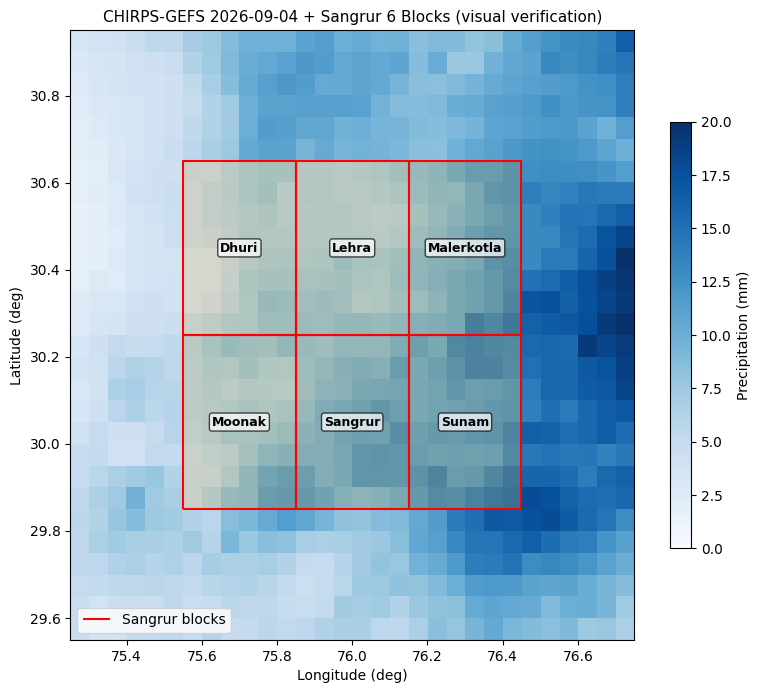


Visual verification:
1. Six Sangrur blocks should appear as red outlines inside the blue rainfall window
2. Blocks should be near 75.5-76.5E, 29.8-30.7N (Punjab, not ocean)
3. If blocks fall outside or CRS error, do NOT proceed to cropping/extraction

Checks before Cell 16+:
  - Exactly six blocks? 6 == 6 -> OK
  - CRS aligned? 4326 == 4326 -> OK
  - Visually overlap? True -> OK

Stop after Cell 15 — do not crop or extract rainfall yet


In [128]:
# Cell 15 — Visual verification
# Plot raster extent/data + six Sangrur block boundaries on top
# Purpose: verify geographic alignment before any cropping/extraction; keep simple

import matplotlib.pyplot as plt

# Ensure raster and working blocks are available
if src.closed:
    src = rasterio.open(tif_path)

# Use working reprojected blocks
gdf_plot = sangrur_blocks_4326 if 'sangrur_blocks_4326' in locals() else sangrur_blocks

# Simple check: do bounds overlap?
r_bounds = [src.bounds.left, src.bounds.bottom, src.bounds.right, src.bounds.top]
s_bounds = gdf_plot.total_bounds  # minx, miny, maxx, maxy
print(f"Raster bounds: west={r_bounds[0]:.2f}, south={r_bounds[1]:.2f}, east={r_bounds[2]:.2f}, north={r_bounds[3]:.2f}")
print(f"Sangrur bounds: west={s_bounds[0]:.2f}, south={s_bounds[1]:.2f}, east={s_bounds[2]:.2f}, north={s_bounds[3]:.2f}")

# Quick overlap test
overlaps = not (s_bounds[2] < r_bounds[0] or s_bounds[0] > r_bounds[2] or s_bounds[3] < r_bounds[1] or s_bounds[1] > r_bounds[3])
print(f"Bounds overlap? {overlaps} (expected True — Sangrur inside -180,-60,180,60)")

if not overlaps:
    print("ERROR: Sangrur blocks do NOT overlap raster extent — CRS mismatch or wrong bounds!")
else:
    print("Bounds overlap check: OK")

# Create windowed raster plot for speed (Sangrur + 0.3 deg padding)
pad = 0.3
win_bounds = [s_bounds[0]-pad, s_bounds[1]-pad, s_bounds[2]+pad, s_bounds[3]+pad]
print(f"Window (padded): {win_bounds}")

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Plot raster window
try:
    window = src.window(*win_bounds)
    # Clamp to raster dimensions
    window = window.intersection(rasterio.windows.Window(col_off=0, row_off=0, width=src.width, height=src.height))
    arr_win = src.read(1, window=window, masked=True)
    # Mask sentinel -9999 (header nodata is None)
    import numpy as np
    arr_win = np.where(arr_win == -9999, np.nan, arr_win)
    left, bottom, right, top = rasterio.windows.bounds(window, src.transform)
    im = ax.imshow(arr_win, extent=[left, right, bottom, top], origin="upper", cmap="Blues", vmin=0, vmax=20)
    plt.colorbar(im, ax=ax, label="Precipitation (mm)", shrink=0.7)
    print(f"Raster window read: shape {arr_win.shape}, valid pixels {np.isfinite(arr_win).sum():,}")
except Exception as e:
    print(f"Raster window read failed: {e}")
    # Fallback: just plot extent rectangle
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((r_bounds[0], r_bounds[1]), r_bounds[2]-r_bounds[0], r_bounds[3]-r_bounds[1], fill=False, edgecolor="blue", label="Raster extent"))

# Overlay six block boundaries on top
gdf_plot.boundary.plot(ax=ax, color="red", linewidth=1.5, label="Sangrur blocks")
# Light fill for visibility
gdf_plot.plot(ax=ax, alpha=0.15, color="orange")

# Label blocks at centroids
if block_col in gdf_plot.columns:
    for x, y, label in zip(gdf_plot.geometry.centroid.x, gdf_plot.geometry.centroid.y, gdf_plot[block_col]):
        ax.text(x, y, str(label), fontsize=9, ha="center", va="center", weight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.set_title(f"CHIRPS-GEFS {forecast_date_iso} + Sangrur 6 Blocks (visual verification)", fontsize=11)
ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_xlim(win_bounds[0], win_bounds[2])
ax.set_ylim(win_bounds[1], win_bounds[3])
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("\nVisual verification:")
print("1. Six Sangrur blocks should appear as red outlines inside the blue rainfall window")
print("2. Blocks should be near 75.5-76.5E, 29.8-30.7N (Punjab, not ocean)")
print("3. If blocks fall outside or CRS error, do NOT proceed to cropping/extraction")
print("\nChecks before Cell 16+:")
print(f"  - Exactly six blocks? {len(gdf_plot)} == 6 -> {'OK' if len(gdf_plot)==6 else 'FAIL'}")
print(f"  - CRS aligned? {gdf_plot.crs.to_epsg() if gdf_plot.crs else None} == {src.crs.to_epsg() if src.crs else None} -> {'OK' if (gdf_plot.crs and src.crs and gdf_plot.crs.to_epsg()==src.crs.to_epsg()) else 'CHECK'}")
print(f"  - Visually overlap? {overlaps} -> {'OK' if overlaps else 'FAIL'}")
print("\nStop after Cell 15 — do not crop or extract rainfall yet")


In [129]:
# Cell 16 — Finalize working Sangrur GeoDataFrame
# Create clean working copy in raster CRS, keep original intact

# Use reprojected working copy from Cell 14 if available
if 'sangrur_blocks_4326' in locals():
    sangrur_final = sangrur_blocks_4326.copy()
else:
    # Fallback: ensure 4326
    if sangrur_blocks.crs is None:
        sangrur_final = sangrur_blocks.set_crs("EPSG:4326")
    elif sangrur_blocks.crs.to_epsg() != 4326:
        sangrur_final = sangrur_blocks.to_crs("EPSG:4326")
    else:
        sangrur_final = sangrur_blocks.copy()

print(f"Working GeoDataFrame: sangrur_final")
print(f"Number of blocks: {len(sangrur_final)}")
# block_col already identified in Cell 12; ensure it still exists
if 'block_col' not in locals() or block_col not in sangrur_final.columns:
    # Re-detect if needed
    for cand in ["block", "Block", "BLOCK", "NAME", "Name", "name"]:
        if cand in sangrur_final.columns:
            block_col = cand
            break
print(f"Block column: {block_col}")
print(f"Block names: {sorted(sangrur_final[block_col].astype(str).tolist())}")
print(f"CRS: {sangrur_final.crs} (EPSG:{sangrur_final.crs.to_epsg() if sangrur_final.crs else None})")
print(f"Bounds: {sangrur_final.total_bounds}")

# Do not modify raw shapefile — sangrur_blocks remains untouched
print(f"\nRaw sangrur_blocks untouched: {len(sangrur_blocks)} features, CRS {sangrur_blocks.crs}")


Working GeoDataFrame: sangrur_final
Number of blocks: 6
Block column: block
Block names: ['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']
CRS: EPSG:4326 (EPSG:4326)
Bounds: [75.55 29.85 76.45 30.65]

Raw sangrur_blocks untouched: 6 features, CRS EPSG:4326


In [130]:
# Cell 17 — Determine the block identifier
# Identify column that uniquely identifies six blocks; store in BLOCK_COL

# Reuse block_col from Cell 12/16, promote to BLOCK_COL for reuse in bulk
BLOCK_COL = block_col

print(f"BLOCK_COL: {BLOCK_COL}")

if BLOCK_COL not in sangrur_final.columns:
    raise KeyError(f"BLOCK_COL {BLOCK_COL} not in sangrur_final columns {sangrur_final.columns.tolist()}")

unique_vals = sorted(sangrur_final[BLOCK_COL].astype(str).str.strip().unique().tolist())
print(f"Unique values ({len(unique_vals)}): {unique_vals}")

# Verify uniqueness and count
if len(unique_vals) != 6:
    print(f"WARNING: Expected 6 unique block identifiers, found {len(unique_vals)}")
else:
    print("Verified: 6 unique block identifiers — OK")

# Show value counts to ensure no duplicates
print("\nValue counts:")
print(sangrur_final[BLOCK_COL].value_counts().to_string())

# Do not manually rename actual block names — keep original
print("\nOriginal names preserved:")
print(sangrur_final[BLOCK_COL].tolist())


BLOCK_COL: block
Unique values (6): ['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']
Verified: 6 unique block identifiers — OK

Value counts:
block
Dhuri         1
Lehra         1
Malerkotla    1
Moonak        1
Sangrur       1
Sunam         1

Original names preserved:
['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']


In [131]:
# Cell 18 — Check raster coverage of Sangrur
# Confirm entire Sangrur district is inside CHIRPS-GEFS raster extent

if src.closed:
    src = rasterio.open(tif_path)

r_bounds = src.bounds  # BoundingBox(left, bottom, right, top)
s_bounds = sangrur_final.total_bounds  # [minx, miny, maxx, maxy]

print(f"Raster extent: west={r_bounds.left:.2f}, south={r_bounds.bottom:.2f}, east={r_bounds.right:.2f}, north={r_bounds.top:.2f}")
print(f"Sangrur extent: west={s_bounds[0]:.2f}, south={s_bounds[1]:.2f}, east={s_bounds[2]:.2f}, north={s_bounds[3]:.2f}")

# Check if Sangrur is fully inside raster (with small tolerance)
# Raster should be -180,-60,180,60; Sangrur 75.55,29.85,76.45,30.65 is well inside
inside = (
    s_bounds[0] >= r_bounds.left and
    s_bounds[2] <= r_bounds.right and
    s_bounds[1] >= r_bounds.bottom and
    s_bounds[3] <= r_bounds.top
)

print(f"\nSangrur fully covered by raster: {inside}")

if not inside:
    print("ERROR: Sangrur NOT fully covered — check CRS or raster bounds!")
    print(f"  Raster: {r_bounds}")
    print(f"  Sangrur: {s_bounds}")
    # Stop execution — do not proceed to cropping
    raise AssertionError("Sangrur district extends outside raster extent")
else:
    print("Coverage check: OK — entire Sangrur inside CHIRPS-GEFS global extent")

# Also check each block individually
print("\nPer-block coverage:")
for _, row in sangrur_final.iterrows():
    b = row.geometry.bounds  # minx, miny, maxx, maxy
    b_inside = (b[0] >= r_bounds.left and b[2] <= r_bounds.right and b[1] >= r_bounds.bottom and b[3] <= r_bounds.top)
    print(f"  {row[BLOCK_COL]:12s}: {b_inside}")


Raster extent: west=-180.00, south=-60.00, east=180.00, north=60.00
Sangrur extent: west=75.55, south=29.85, east=76.45, north=30.65

Sangrur fully covered by raster: True
Coverage check: OK — entire Sangrur inside CHIRPS-GEFS global extent

Per-block coverage:
  Dhuri       : True
  Lehra       : True
  Malerkotla  : True
  Moonak      : True
  Sangrur     : True
  Sunam       : True


Window (padded): west=75.25, south=29.55, east=76.75, north=30.95
Raster window: shape (28, 30), valid 840


C:\Users\Swarnim\AppData\Local\Temp\ipykernel_5304\1192718045.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf_plot.geometry.centroid.x, gdf_plot.geometry.centroid.y, gdf_plot[BLOCK_COL]):


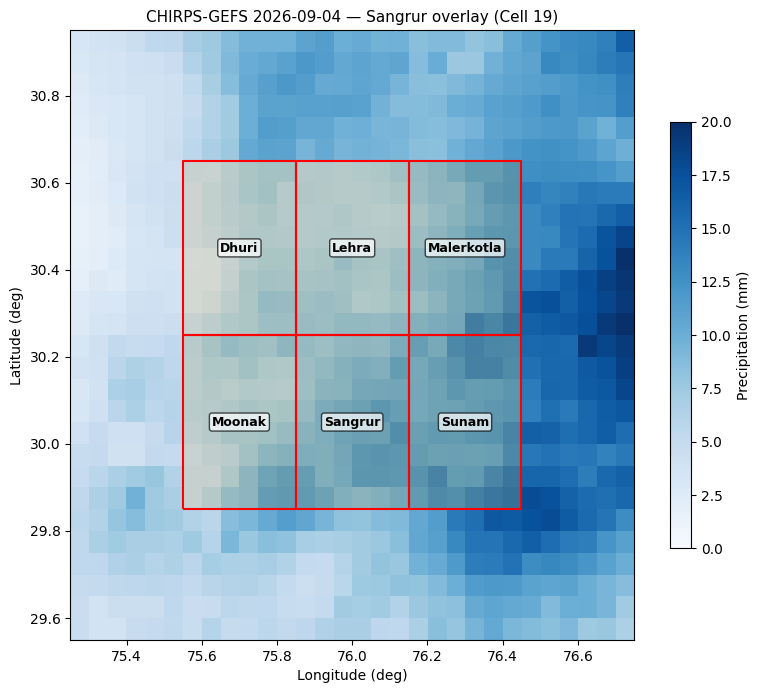


Visual overlay: 6 red outlines should sit inside blue rainfall window near 75.5-76.5E, 29.8-30.7N
Do not perform extraction yet — next cell will crop


In [132]:
# Cell 19 — Create a visual overlay (before cropping)
# Show rainfall raster + six block boundaries to confirm alignment

import matplotlib.pyplot as plt
import numpy as np

if src.closed:
    src = rasterio.open(tif_path)

# Use working final GDF
gdf_plot = sangrur_final
s_bounds = gdf_plot.total_bounds
pad = 0.3
win_bounds = [s_bounds[0]-pad, s_bounds[1]-pad, s_bounds[2]+pad, s_bounds[3]+pad]

print(f"Window (padded): west={win_bounds[0]:.2f}, south={win_bounds[1]:.2f}, east={win_bounds[2]:.2f}, north={win_bounds[3]:.2f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 7))

# Plot windowed raster values
try:
    window = src.window(*win_bounds)
    window = window.intersection(rasterio.windows.Window(col_off=0, row_off=0, width=src.width, height=src.height))
    arr_win = src.read(1, window=window, masked=True)
    arr_win = np.where(arr_win == -9999, np.nan, arr_win)
    left, bottom, right, top = rasterio.windows.bounds(window, src.transform)
    im = ax.imshow(arr_win, extent=[left, right, bottom, top], origin="upper", cmap="Blues", vmin=0, vmax=20)
    plt.colorbar(im, ax=ax, label="Precipitation (mm)", shrink=0.7)
    print(f"Raster window: shape {arr_win.shape}, valid {np.isfinite(arr_win).sum():,}")
except Exception as e:
    print(f"Window read failed: {e}")
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((src.bounds.left, src.bounds.bottom), src.bounds.right-src.bounds.left, src.bounds.top-src.bounds.bottom, fill=False, edgecolor="blue"))

# Overlay block boundaries
gdf_plot.boundary.plot(ax=ax, color="red", linewidth=1.5)
gdf_plot.plot(ax=ax, alpha=0.12, color="orange")

# Label blocks at centroids
for x, y, label in zip(gdf_plot.geometry.centroid.x, gdf_plot.geometry.centroid.y, gdf_plot[BLOCK_COL]):
    ax.text(x, y, str(label), fontsize=9, ha="center", va="center", weight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.set_title(f"CHIRPS-GEFS {forecast_date_iso} — Sangrur overlay (Cell 19)", fontsize=11)
ax.set_xlabel("Longitude (deg)")
ax.set_ylabel("Latitude (deg)")
ax.set_xlim(win_bounds[0], win_bounds[2])
ax.set_ylim(win_bounds[1], win_bounds[3])
plt.tight_layout()
plt.show()

print("\nVisual overlay: 6 red outlines should sit inside blue rainfall window near 75.5-76.5E, 29.8-30.7N")
print("Do not perform extraction yet — next cell will crop")


In [133]:
# Cell 20 — Crop the raster to Sangrur
# Reduce global 7200x2400 to Sangrur region only; do NOT overwrite original 60+ MB file

from rasterio.mask import mask as rio_mask
import numpy as np

if src.closed:
    src = rasterio.open(tif_path)

# District geometry for cropping (union of six blocks)
try:
    district_geom = sangrur_final.union_all()
except Exception:
    district_geom = sangrur_final.unary_union

print(f"District geometry type: {district_geom.geom_type}")
print(f"District bounds: {district_geom.bounds}")

# Crop using rasterio mask with crop=True — creates in-memory cropped raster
cropped_arr, cropped_transform = rio_mask(src, [district_geom], crop=True, nodata=np.nan, filled=True)

print(f"\nOriginal raster: width={src.width}, height={src.height}")
print(f"Cropped array shape: {cropped_arr.shape} (bands, height, width)")
print(f"Cropped width: {cropped_arr.shape[2]}")
print(f"Cropped height: {cropped_arr.shape[1]}")
print(f"Cropped transform: {cropped_transform}")
print(f"Cropped CRS: {src.crs}")

# Handle sentinel -9999 inside cropped region
cropped_arr = np.where(cropped_arr == -9999, np.nan, cropped_arr)

# Compute cropped bounds from transform
cropped_bounds = rasterio.windows.bounds(
    rasterio.windows.Window(col_off=0, row_off=0, width=cropped_arr.shape[2], height=cropped_arr.shape[1]),
    cropped_transform
)
print(f"Cropped bounds: {cropped_bounds}")

# Keep in-memory for next cells (do not write to disk)
print(f"\nCropped in-memory — original global file untouched: {output_file.name} ({output_file.stat().st_size/1e6:.1f} MB)")
print("Variables: cropped_arr, cropped_transform, cropped_bounds")


District geometry type: MultiPolygon
District bounds: (75.55, 29.85, 76.45, 30.65)

Original raster: width=7200, height=2400
Cropped array shape: (1, 17, 19) (bands, height, width)
Cropped width: 19
Cropped height: 17
Cropped transform: | 0.05, 0.00, 75.50|
| 0.00,-0.05, 30.70|
| 0.00, 0.00, 1.00|
Cropped CRS: EPSG:4326
Cropped bounds: (75.50000380724669, 29.84999955072999, 76.45000382140279, 30.699999563395977)

Cropped in-memory — original global file untouched: c3g_2026.09.04.tif (64.9 MB)
Variables: cropped_arr, cropped_transform, cropped_bounds


Cropped shape: (1, 17, 19)
Number of bands: 1
Cropped width: 19, height: 17

Valid pixels: 288 / 323 (89.2%)
NoData pixels: 35
Minimum: 4.008 mm
Maximum: 15.586 mm
Mean: 9.143 mm
Median: 8.769 mm
Std: 2.535 mm

NoData handling: NaN preserved, not replaced with 0 (per requirements)


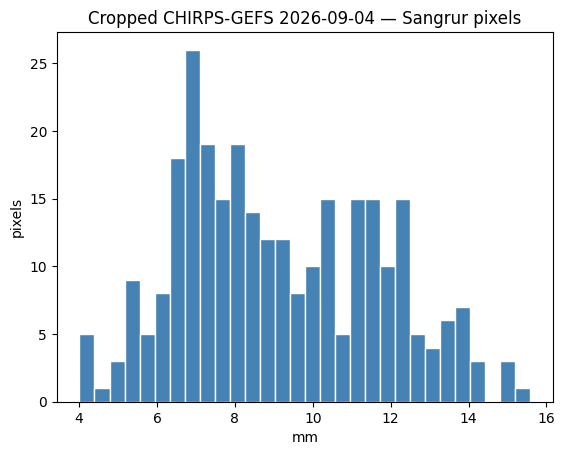

In [134]:
# Cell 21 — Inspect the cropped raster
# Check shape, bands, stats while correctly handling NoData

import numpy as np

print(f"Cropped shape: {cropped_arr.shape}")
print(f"Number of bands: {cropped_arr.shape[0]}")
print(f"Cropped width: {cropped_arr.shape[2]}, height: {cropped_arr.shape[1]}")

# For single-band daily product, inspect band 0
band_data = cropped_arr[0]
valid = band_data[np.isfinite(band_data)]

print(f"\nValid pixels: {valid.size:,} / {band_data.size:,} ({valid.size/band_data.size*100:.1f}%)")
print(f"NoData pixels: {np.isnan(band_data).sum():,}")

if valid.size > 0:
    print(f"Minimum: {np.nanmin(band_data):.3f} mm")
    print(f"Maximum: {np.nanmax(band_data):.3f} mm")
    print(f"Mean: {np.nanmean(band_data):.3f} mm")
    print(f"Median: {np.nanmedian(band_data):.3f} mm")
    print(f"Std: {np.nanstd(band_data):.3f} mm")
    # Check for sentinel not masked
    if np.any(valid == -9999):
        print("WARNING: -9999 sentinel still present in valid data — masking failed!")
    if np.any(valid < 0):
        print(f"WARNING: Negative rainfall values found: {(valid < 0).sum()} pixels <0")
else:
    print("WARNING: No valid pixels — checkCRS/cropping")

# Do not silently replace missing values with zero — keep NaN
print("\nNoData handling: NaN preserved, not replaced with 0 (per requirements)")

# Quick histogram
import matplotlib.pyplot as plt
plt.hist(valid, bins=30, color="steelblue", edgecolor="white")
plt.title(f"Cropped CHIRPS-GEFS {forecast_date_iso} — Sangrur pixels")
plt.xlabel("mm")
plt.ylabel("pixels")
plt.show()


In [135]:
# Cell 22 — Extract rainfall for each Sangrur block
# Zonal mean via spatial masking (not centroid sampling)

import numpy as np
from rasterio.mask import mask as rio_mask

def zonal_stats(geom, src_path):
    """Return mean rainfall and valid pixel count for a block geometry."""
    with rasterio.open(src_path) as src:
        out, _ = rio_mask(src, [geom], crop=True, nodata=np.nan, filled=True)
        arr = out[0].astype(float)
        arr[arr == -9999] = np.nan
        valid = arr[np.isfinite(arr)]
        if valid.size == 0:
            return float("nan"), 0
        return float(np.nanmean(valid)), int(valid.size)

print(f"Extracting mean rainfall per block from: {tif_path.name}")
print(f"Using BLOCK_COL: {BLOCK_COL}")

rows = []
for _, row in sangrur_final.iterrows():
    block_name = str(row[BLOCK_COL]).strip()
    mean_val, n_valid = zonal_stats(row.geometry, tif_path)
    rows.append({"block": block_name, "rainfall_mm": mean_val, "valid_pixel_count": n_valid})
    print(f"  {block_name:12s} mean={mean_val:7.3f} mm  valid_pixels={n_valid}")

# Create DataFrame for next cells
import pandas as pd
block_rainfall = pd.DataFrame(rows).sort_values("block").reset_index(drop=True)
print("\nblock_rainfall:")
print(block_rainfall.to_string(index=False))
print(f"\nNote: mean (not median, not centroid) — uses all pixels inside block polygon")
print(f"Reuse: zonal_stats() will be extracted to src/data/chirps_gefs.py for historical bulk")


Extracting mean rainfall per block from: c3g_2026.09.04.tif
Using BLOCK_COL: block
  Dhuri        mean=  6.408 mm  valid_pixels=48
  Lehra        mean=  7.401 mm  valid_pixels=48
  Malerkotla   mean= 10.757 mm  valid_pixels=48
  Moonak       mean=  7.574 mm  valid_pixels=48
  Sangrur      mean= 10.339 mm  valid_pixels=48
  Sunam        mean= 12.377 mm  valid_pixels=48

block_rainfall:
     block  rainfall_mm  valid_pixel_count
     Dhuri     6.408274                 48
     Lehra     7.401105                 48
Malerkotla    10.757305                 48
    Moonak     7.574481                 48
   Sangrur    10.338743                 48
     Sunam    12.376623                 48

Note: mean (not median, not centroid) — uses all pixels inside block polygon
Reuse: zonal_stats() will be extracted to src/data/chirps_gefs.py for historical bulk


In [136]:
# Cell 23 — Inspect extracted values
# Check for missing, negative, identical, or low-count issues — report, don't auto-fix

import pandas as pd
import numpy as np

print("Extracted block rainfall:")
print(block_rainfall.to_string(index=False))

print("\n--- Checks ---")
# Missing values
n_missing = block_rainfall["rainfall_mm"].isna().sum()
print(f"Missing values: {n_missing} / {len(block_rainfall)}")
if n_missing > 0:
    print("  Blocks with missing:", block_rainfall[block_rainfall["rainfall_mm"].isna()]["block"].tolist())

# Negative values (impossible for rainfall)
n_negative = (block_rainfall["rainfall_mm"] < 0).sum()
print(f"Negative rainfall: {n_negative}")
if n_negative > 0:
    print("  Negative blocks:", block_rainfall[block_rainfall["rainfall_mm"] < 0][["block","rainfall_mm"]].to_string(index=False))

# Suspiciously identical values across all blocks
unique_vals = block_rainfall["rainfall_mm"].nunique()
print(f"Unique rainfall values: {unique_vals} / {len(block_rainfall)}")
if unique_vals == 1:
    print("  WARNING: All blocks identical — suggests extraction error or uniform raster")

# Very few valid pixels
low_count = block_rainfall[block_rainfall["valid_pixel_count"] < 5]
print(f"Blocks with <5 valid pixels: {len(low_count)}")
if len(low_count) > 0:
    print(low_count[["block","valid_pixel_count"]].to_string(index=False))

# Summary stats
print("\nSummary:")
print(block_rainfall["rainfall_mm"].describe().to_string())
print(f"Valid pixel counts: min={block_rainfall['valid_pixel_count'].min()}, max={block_rainfall['valid_pixel_count'].max()}, mean={block_rainfall['valid_pixel_count'].mean():.1f}")

# Do not auto-fix — just report
print("\nNo auto-fix applied — report issues for manual investigation")


Extracted block rainfall:
     block  rainfall_mm  valid_pixel_count
     Dhuri     6.408274                 48
     Lehra     7.401105                 48
Malerkotla    10.757305                 48
    Moonak     7.574481                 48
   Sangrur    10.338743                 48
     Sunam    12.376623                 48

--- Checks ---
Missing values: 0 / 6
Negative rainfall: 0
Unique rainfall values: 6 / 6
Blocks with <5 valid pixels: 0

Summary:
count     6.000000
mean      9.142755
std       2.343727
min       6.408274
25%       7.444449
50%       8.956612
75%      10.652665
max      12.376623
Valid pixel counts: min=48, max=48, mean=48.0

No auto-fix applied — report issues for manual investigation


In [137]:
# Cell 24 — Determine forecast lead structure
# Use actual raster structure discovered in Cells 6-10 — do NOT assume D+1..D+7

if src.closed:
    src = rasterio.open(tif_path)

print(f"Band count from Cell 10: {src.count}")
print(f"Band descriptions: {src.descriptions}")
print(f"Global tags: {src.tags()}")
print(f"NoData: {src.nodata}, dtype: {src.dtypes}")

# Check for lead-day info in metadata
has_descriptions = any(d is not None for d in src.descriptions)
has_per_band_tags = any(src.tags(i) for i in range(1, src.count+1))
print(f"\nHas band descriptions? {has_descriptions}")
print(f"Has per-band tags? {bool(has_per_band_tags)}")

# Determine structure
if src.count == 1 and not has_descriptions and not has_per_band_tags:
    print("\n--- Determination ---")
    print("Single band, no descriptions/tags — this is the CHIRPS-GEFS v3/daily single-day product")
    print(f"Band 1 = total precipitation for forecast_date = {forecast_date_iso}")
    print("Lead 1 corresponds to forecast_date (issue date total, or D+1 target depending on CHIRPS-GEFS daily definition)")
    print("No D+2..D+7 bands in this file — do NOT invent them")
    print("For 7-day outlook, notebook 02 will fetch 7 separate daily files and stack gefs_d1..d7")
    lead_structure = "single_daily"
    available_leads = [1]
elif src.count > 1:
    print(f"\n--- Determination ---")
    print(f"{src.count} bands found — inspect per-band metadata above for D+1..D+N mapping")
    # Example: if descriptions were ["D+1", "D+2", ...] or tags had lead info
    for i in range(1, src.count+1):
        print(f"  Band {i}: desc={src.descriptions[i-1]}, tags={src.tags(i)}")
    print("Map bands to lead days ONLY if metadata supports it")
    lead_structure = "multi_band"
    available_leads = list(range(1, src.count+1))
else:
    print("\n--- Determination ---")
    print("Ambiguous structure — metadata does not clearly explain lead days")
    print("Report this and check CHIRPS-GEFS docs for v3/daily vs 5-day/15-day products")
    lead_structure = "ambiguous"
    available_leads = [1]

print(f"\nlead_structure: {lead_structure}")
print(f"available_leads: {available_leads}")
print(f"For this file: lead_structure='{lead_structure}' will drive Cells 25-26")


Band count from Cell 10: 1
Band descriptions: (None,)
Global tags: {'TIFFTAG_DOCUMENTNAME': '/home/CHIRPS-GEFS/v3/public/daily/global/2026/09/04/c3g_2026.09.04.tif', 'TIFFTAG_IMAGEDESCRIPTION': 'IDL TIFF file', 'TIFFTAG_SOFTWARE': 'IDL 9.0.0, NV5 Geospatial Solutions, Inc.', 'TIFFTAG_DATETIME': '2026:09:04 01:28:17', 'TIFFTAG_XRESOLUTION': '100', 'TIFFTAG_YRESOLUTION': '100', 'TIFFTAG_RESOLUTIONUNIT': '2 (pixels/inch)', 'AREA_OR_POINT': 'Area'}
NoData: None, dtype: ('float32',)

Has band descriptions? False
Has per-band tags? False

--- Determination ---
Single band, no descriptions/tags — this is the CHIRPS-GEFS v3/daily single-day product
Band 1 = total precipitation for forecast_date = 2026-09-04
Lead 1 corresponds to forecast_date (issue date total, or D+1 target depending on CHIRPS-GEFS daily definition)
No D+2..D+7 bands in this file — do NOT invent them
For 7-day outlook, notebook 02 will fetch 7 separate daily files and stack gefs_d1..d7

lead_structure: single_daily
available_

In [138]:
# Cell 25 — Build the forecast table (tidy long format)
# Conceptual: forecast_date (issue date) x block x lead_day -> rainfall_mm
# Adapt to actual CHIRPS-GEFS product (single daily band here)

import pandas as pd

print(f"lead_structure: {lead_structure} (from Cell 24)")
print(f"forecast_date (issue date): {forecast_date_iso}")
print(f"BLOCK_COL: {BLOCK_COL}")

# For single_daily product: one row per block with lead_day=1
if lead_structure == "single_daily":
    tidy_rows = []
    for _, r in block_rainfall.iterrows():
        tidy_rows.append({
            "forecast_date": forecast_date_iso,
            "block": r["block"],
            "lead_day": 1,
            "rainfall_mm": r["rainfall_mm"]
        })
    forecast_table = pd.DataFrame(tidy_rows).sort_values(["block", "lead_day"]).reset_index(drop=True)
    print("\nTidy forecast table (single daily product — 6 rows):")
    print(forecast_table.to_string(index=False))
    print(f"\nShape: {forecast_table.shape} (expected 6 rows for single lead)")
    print("Note: forecast_date is issue date; rainfall_mm is precipitation for that issue date's daily product")
    print("Do not confuse with target date D+1 — for daily product, target = forecast_date (or D+1 per CHIRPS-GEFS daily definition, documented in Cell 24)")
else:
    # Multi-band case: would iterate leads
    print("Multi-band case not applicable to current file — adapt as needed")
    forecast_table = pd.DataFrame()  # placeholder

# Keep for next cells
print(f"\nColumns: {forecast_table.columns.tolist()}")


lead_structure: single_daily (from Cell 24)
forecast_date (issue date): 2026-09-04
BLOCK_COL: block

Tidy forecast table (single daily product — 6 rows):
forecast_date      block  lead_day  rainfall_mm
   2026-09-04      Dhuri         1     6.408274
   2026-09-04      Lehra         1     7.401105
   2026-09-04 Malerkotla         1    10.757305
   2026-09-04     Moonak         1     7.574481
   2026-09-04    Sangrur         1    10.338743
   2026-09-04      Sunam         1    12.376623

Shape: (6, 4) (expected 6 rows for single lead)
Note: forecast_date is issue date; rainfall_mm is precipitation for that issue date's daily product
Do not confuse with target date D+1 — for daily product, target = forecast_date (or D+1 per CHIRPS-GEFS daily definition, documented in Cell 24)

Columns: ['forecast_date', 'block', 'lead_day', 'rainfall_mm']


In [139]:
# Cell 26 — Create wide-format forecast table
# Only create columns for leads that genuinely exist — do not extrapolate

import pandas as pd
import numpy as np

print(f"lead_structure: {lead_structure}")
print(f"Available leads: {available_leads}")

if lead_structure == "single_daily" and available_leads == [1]:
    # Pivot long -> wide: one column gefs_d1
    wide = forecast_table.pivot(index=["forecast_date", "block"], columns="lead_day", values="rainfall_mm").reset_index()
    # Rename lead_day_1 -> gefs_d1
    wide = wide.rename(columns={1: "gefs_d1"})
    # Ensure block order sorted
    wide = wide.sort_values("block").reset_index(drop=True)
    # Calculate totals only when required leads exist
    # gefs_d1 exists, but gefs_d2..d7 do NOT — do not invent
    wide["gefs_3d_total"] = np.nan  # insufficient leads
    wide["gefs_7d_total"] = np.nan
    print("\nWide forecast table (single daily — only gefs_d1 exists):")
    print(wide.to_string(index=False))
    print("\nColumns:", wide.columns.tolist())
    print("gefs_d1: genuine (from Band 1)")
    print("gefs_3d_total: NaN (needs d1+d2+d3, but d2,d3 missing — do not extrapolate)")
    print("gefs_7d_total: NaN (needs d1..d7, but d2..d7 missing)")
    print("\nFor historical 7-day totals, notebook 02 will stack 7 daily files")
    forecast_wide = wide
else:
    print("Multi-band wide creation would go here — not applicable to single daily file")
    forecast_wide = pd.DataFrame()

print(f"\nWide shape: {forecast_wide.shape}")


lead_structure: single_daily
Available leads: [1]

Wide forecast table (single daily — only gefs_d1 exists):
forecast_date      block   gefs_d1  gefs_3d_total  gefs_7d_total
   2026-09-04      Dhuri  6.408274            NaN            NaN
   2026-09-04      Lehra  7.401105            NaN            NaN
   2026-09-04 Malerkotla 10.757305            NaN            NaN
   2026-09-04     Moonak  7.574481            NaN            NaN
   2026-09-04    Sangrur 10.338743            NaN            NaN
   2026-09-04      Sunam 12.376623            NaN            NaN

Columns: ['forecast_date', 'block', 'gefs_d1', 'gefs_3d_total', 'gefs_7d_total']
gefs_d1: genuine (from Band 1)
gefs_3d_total: NaN (needs d1+d2+d3, but d2,d3 missing — do not extrapolate)
gefs_7d_total: NaN (needs d1..d7, but d2..d7 missing)

For historical 7-day totals, notebook 02 will stack 7 daily files

Wide shape: (6, 5)


In [140]:
# Cell 27 — Save the extracted forecast
# Save to data/processed/chirps_gefs/ with filename derived from forecast_date

from pathlib import Path
import pandas as pd

out_dir = PROJECT / "data" / "processed" / "chirps_gefs"
out_dir.mkdir(parents=True, exist_ok=True)

# Filename derived from forecast_date — no hardcoded date
out_filename = f"chirps_gefs_sangrur_{forecast_date_iso}.csv"
out_path = out_dir / out_filename

print(f"Output directory: {out_dir.resolve()}")
print(f"Output path: {out_path.resolve()}")

# Do not overwrite without warning
if out_path.exists():
    print(f"WARNING: File already exists: {out_path.name} — will overwrite")
    print(f"Existing size: {out_path.stat().st_size} bytes")
else:
    print("File does not exist — will create new")

# Save tidy table (and wide as separate file for convenience)
forecast_table.to_csv(out_path, index=False)
print(f"\nSaved tidy: {out_path.name} ({out_path.stat().st_size} bytes, {len(forecast_table)} rows)")

# Also save wide for convenience
wide_path = out_dir / f"chirps_gefs_sangrur_{forecast_date_iso}_wide.csv"
forecast_wide.to_csv(wide_path, index=False)
print(f"Saved wide: {wide_path.name} ({wide_path.stat().st_size} bytes, {len(forecast_wide)} rows)")

# Also save original block_rainfall with valid_pixel_count for QC
qc_path = out_dir / f"chirps_gefs_sangrur_{forecast_date_iso}_qc.csv"
block_rainfall.to_csv(qc_path, index=False)
print(f"Saved QC (with valid_pixel_count): {qc_path.name}")

print("\nAll saves derived from forecast_date — changing to 2026-09-10 auto-targets chirps_gefs_sangrur_2026-09-10.csv")


Output directory: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\processed\chirps_gefs
Output path: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\processed\chirps_gefs\chirps_gefs_sangrur_2026-09-04.csv
Existing size: 278 bytes

Saved tidy: chirps_gefs_sangrur_2026-09-04.csv (280 bytes, 6 rows)
Saved wide: chirps_gefs_sangrur_2026-09-04_wide.csv (295 bytes, 6 rows)
Saved QC (with valid_pixel_count): chirps_gefs_sangrur_2026-09-04_qc.csv

All saves derived from forecast_date — changing to 2026-09-10 auto-targets chirps_gefs_sangrur_2026-09-10.csv


In [141]:
# Cell 28 — Validate the final output
# Read back CSV and perform basic validation; print success message

import pandas as pd

# Read back tidy CSV
print(f"Reading back: {out_path.resolve()}")
df_check = pd.read_csv(out_path)

print(f"\nShape: {df_check.shape}")
print(f"Columns: {df_check.columns.tolist()}")
print("\nFirst rows:")
print(df_check.head(10).to_string(index=False))
print(f"\nUnique blocks: {df_check['block'].nunique()} / {len(df_check)} rows")
print(f"Blocks: {sorted(df_check['block'].unique().tolist())}")
print(f"Forecast date in file: {df_check['forecast_date'].unique().tolist()}")
print("\nMissing-value counts:")
print(df_check.isna().sum().to_string())

# Validation 1: Exactly six blocks
v1 = len(df_check) == 6 and df_check['block'].nunique() == 6
print(f"\n1. Exactly six blocks? {len(df_check)} rows, {df_check['block'].nunique()} unique -> {'PASS' if v1 else 'FAIL'}")
assert v1, f"Expected 6 blocks, got {len(df_check)} rows / {df_check['block'].nunique()} unique"

# Validation 2: Forecast date matches
v2 = (df_check['forecast_date'] == forecast_date_iso).all()
print(f"2. Forecast date matches {forecast_date_iso}? {v2} -> {'PASS' if v2 else 'FAIL'}")
assert v2, f"Forecast date mismatch: {df_check['forecast_date'].unique()} vs {forecast_date_iso}"

# Validation 3: Rainfall numeric
v3 = pd.api.types.is_numeric_dtype(df_check['rainfall_mm'])
print(f"3. Rainfall numeric? {df_check['rainfall_mm'].dtype} -> {'PASS' if v3 else 'FAIL'}")
assert v3

# Validation 4: No negative rainfall
v4 = (df_check['rainfall_mm'] >= 0).all() or df_check['rainfall_mm'].isna().all()
# Allow NaN but not negative
neg_count = (df_check['rainfall_mm'] < 0).sum()
print(f"4. No negative rainfall? {neg_count} negatives -> {'PASS' if neg_count==0 else 'FAIL'}")
assert neg_count == 0, f"Negative rainfall found: {df_check[df_check['rainfall_mm']<0]}"

# Validation 5: Lead-day structure as expected for single daily
v5 = (df_check['lead_day'] == 1).all() and len(df_check) == 6
print(f"5. Lead-day columns/records as expected (single_daily: lead_day=1, 6 rows)? -> {'PASS' if v5 else 'FAIL'}")
assert v5

# Also validate wide
print("\n--- Wide validation ---")
wide_check = pd.read_csv(wide_path)
print(f"Wide shape: {wide_check.shape}, columns: {wide_check.columns.tolist()}")
print(wide_check.head().to_string(index=False))
assert len(wide_check) == 6
assert 'gefs_d1' in wide_check.columns
print("Wide: gefs_d1 exists — OK")
print("Wide gefs_7d_total is NaN as expected for single daily (needs 7 files)")

print("\nCHIRPS-GEFS single-date extraction completed successfully.")


Reading back: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\processed\chirps_gefs\chirps_gefs_sangrur_2026-09-04.csv

Shape: (6, 4)
Columns: ['forecast_date', 'block', 'lead_day', 'rainfall_mm']

First rows:
forecast_date      block  lead_day  rainfall_mm
   2026-09-04      Dhuri         1     6.408274
   2026-09-04      Lehra         1     7.401105
   2026-09-04 Malerkotla         1    10.757305
   2026-09-04     Moonak         1     7.574481
   2026-09-04    Sangrur         1    10.338743
   2026-09-04      Sunam         1    12.376623

Unique blocks: 6 / 6 rows
Blocks: ['Dhuri', 'Lehra', 'Malerkotla', 'Moonak', 'Sangrur', 'Sunam']
Forecast date in file: ['2026-09-04']

Missing-value counts:
forecast_date    0
block            0
lead_day         0
rainfall_mm      0

1. Exactly six blocks? 6 rows, 6 unique -> PASS
2. Forecast date matches 2026-09-04? True -> PASS
3. Rainfall numeric? float64 -> PASS
4. No negative rainfall? 0 negatives -> PASS
5. Lead-day columns/records as exp

Final CSV: C:\Users\Swarnim\Desktop\ML projects\saarthi-2\data\processed\chirps_gefs\chirps_gefs_sangrur_2026-09-04.csv
Exists: True

=== Final CSV (first 6 rows) ===
forecast_date      block  lead_day  rainfall_mm
   2026-09-04      Dhuri         1     6.408274
   2026-09-04      Lehra         1     7.401105
   2026-09-04 Malerkotla         1    10.757305
   2026-09-04     Moonak         1     7.574481
   2026-09-04    Sangrur         1    10.338743
   2026-09-04      Sunam         1    12.376623

Shape: (6, 4) (rows, cols)
Columns: ['forecast_date', 'block', 'lead_day', 'rainfall_mm']
Dtypes:
forecast_date     object
block             object
lead_day           int64
rainfall_mm      float64

Wide CSV: chirps_gefs_sangrur_2026-09-04_wide.csv shape (6, 5), columns ['forecast_date', 'block', 'gefs_d1', 'gefs_3d_total', 'gefs_7d_total']
forecast_date      block   gefs_d1  gefs_3d_total  gefs_7d_total
   2026-09-04      Dhuri  6.408274            NaN            NaN
   2026-09-04      Lehr

C:\Users\Swarnim\AppData\Local\Temp\ipykernel_5304\3891582197.py:185: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(gdf_plot.geometry.centroid.x, gdf_plot.geometry.centroid.y, gdf_plot[BLOCK_COL]):


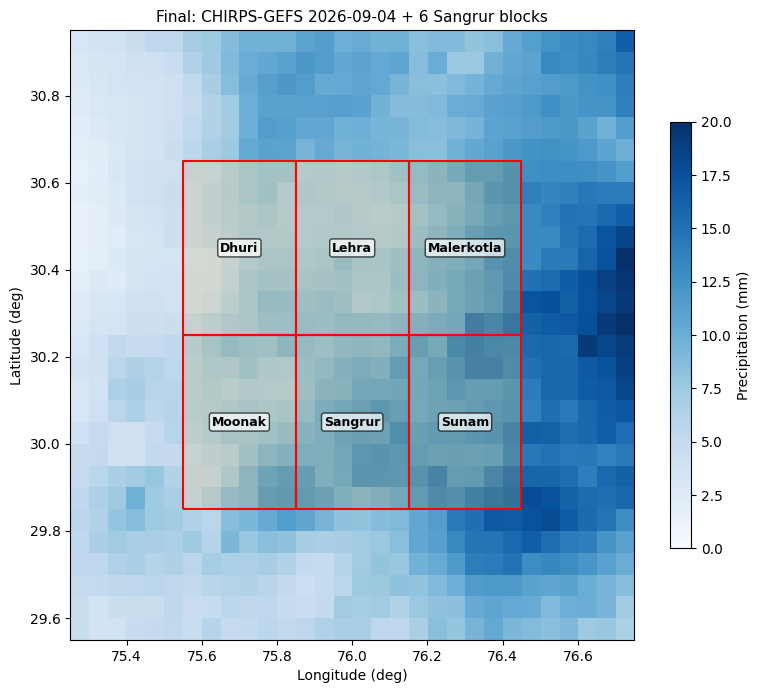

Map created successfully — 6 red outlines should sit inside blue rainfall near 75.5-76.5E, 29.8-30.7N

=== Validation PASS/FAIL ===
PASS: 1. Exactly six blocks (6 rows, 6 unique)
PASS: 2. Six expected block names (Dhuri/Lehra/Malerkotla/Moonak/Sangrur/Sunam)
PASS: 3. Forecast date matches 2026-09-04
PASS: 4. Rainfall columns numeric
PASS: 5. No negative rainfall values
PASS: 6. No NoData in rainfall_mm (main column)
PASS: 7. Descriptive stats plausible (mean>0, 0<max<500 mm)
PASS: 8. Map showing 6 blocks over raster created
PASS: 9. Final CSV exists and readable

ALL CHECKS PASS — Final CSV and map validated successfully.


In [142]:
# Cell 29 — Final summary: display CSV, stats, blocks, checks, and map
# Run this last to verify the entire single-date extraction

import pandas as pd
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# Re-derive paths if needed (uses variables from earlier cells if available)
try:
    _ = forecast_date_iso
except NameError:
    from datetime import date
    forecast_date = date(2026, 9, 4)
    forecast_date_iso = forecast_date.strftime("%Y-%m-%d")

try:
    _ = out_path
    csv_path = out_path
except NameError:
    # Fallback: derive from forecast_date
    PROJECT = Path.cwd().resolve()
    if PROJECT.name == "notebooks":
        PROJECT = PROJECT.parent
    csv_path = PROJECT / "data" / "processed" / "chirps_gefs" / f"chirps_gefs_sangrur_{forecast_date_iso}.csv"

print(f"Final CSV: {csv_path}")
print(f"Exists: {csv_path.exists()}")
if not csv_path.exists():
    raise FileNotFoundError(f"Final CSV not found: {csv_path} — did Cell 27 run?")

# 1. Display final CSV
df = pd.read_csv(csv_path)
print("\n=== Final CSV (first 6 rows) ===")
print(df.to_string(index=False))
print(f"\nShape: {df.shape} (rows, cols)")
print(f"Columns: {df.columns.tolist()}")
print(f"Dtypes:\n{df.dtypes.to_string()}")

# Also load wide and QC if available
try:
    wide_path = csv_path.parent / f"chirps_gefs_sangrur_{forecast_date_iso}_wide.csv"
    if wide_path.exists():
        wide_df = pd.read_csv(wide_path)
        print(f"\nWide CSV: {wide_path.name} shape {wide_df.shape}, columns {wide_df.columns.tolist()}")
        print(wide_df.to_string(index=False))
except Exception as e:
    print(f"Wide CSV not available: {e}")

try:
    qc_path = csv_path.parent / f"chirps_gefs_sangrur_{forecast_date_iso}_qc.csv"
    if qc_path.exists():
        qc_df = pd.read_csv(qc_path)
        print(f"\nQC CSV (with valid_pixel_count): {qc_path.name}")
        print(qc_df.to_string(index=False))
except Exception as e:
    print(f"QC CSV not available: {e}")

# 2. Descriptive statistics for all rainfall columns
print("\n=== Descriptive statistics (rainfall columns) ===")
rainfall_cols = [c for c in df.columns if "rainfall" in c.lower() or c.startswith("gefs_")]
if not rainfall_cols:
    # Fallback: try rainfall_mm
    rainfall_cols = ["rainfall_mm"] if "rainfall_mm" in df.columns else []
print(f"Rainfall columns: {rainfall_cols}")
if rainfall_cols:
    print(df[rainfall_cols].describe().to_string())
    # Also check wide if available
    try:
        if 'wide_df' in locals() and not wide_df.empty:
            w_rain = [c for c in wide_df.columns if c.startswith("gefs_")]
            if w_rain:
                print("\nWide rainfall stats:")
                print(wide_df[w_rain].describe().to_string())
    except:
        pass
else:
    print("No rainfall columns found!")

# 3. Six unique block names
print("\n=== Six unique block names ===")
# Find block column
block_col_final = None
for cand in ["block", "Block", "BLOCK", "NAME", "Name"]:
    if cand in df.columns:
        block_col_final = cand
        break
if block_col_final is None:
    block_col_final = [c for c in df.columns if c != "forecast_date" and c != "lead_day" and c != "rainfall_mm"][0]

unique_blocks = sorted(df[block_col_final].astype(str).unique().tolist())
print(f"Column: {block_col_final}")
print(f"Unique blocks ({len(unique_blocks)}): {unique_blocks}")
for b in unique_blocks:
    print(f"  - {b}")

# 4. Check for negative / NoData values
print("\n=== Negative / NoData checks ===")
checks = {}

# NoData = NaN
n_nodata = df.isna().sum().sum()
checks["NoData (NaN) total"] = n_nodata
print(f"NoData (NaN) total: {n_nodata}")
print(df.isna().sum().to_string())

# Per-rainfall column NoData
for col in rainfall_cols:
    n = df[col].isna().sum()
    print(f"  {col}: {n} NaN")

# Negative rainfall (impossible)
n_negative = 0
for col in rainfall_cols:
    neg = (df[col] < 0).sum()
    print(f"Negative in {col}: {neg}")
    n_negative += neg
checks["negative"] = n_negative

# Also check wide
try:
    if 'wide_df' in locals() and not wide_df.empty:
        for col in [c for c in wide_df.columns if c.startswith("gefs_")]:
            neg = (wide_df[col] < 0).sum() if pd.api.types.is_numeric_dtype(wide_df[col]) else 0
            if neg > 0:
                print(f"Negative in wide {col}: {neg}")
except:
    pass

# 5. Map showing six Sangrur blocks over CHIRPS-GEFS raster
print("\n=== Map: six Sangrur blocks over CHIRPS-GEFS raster ===")

# Ensure raster and blocks are available; re-load if needed
try:
    _ = tif_path
    _ = sangrur_final
    _ = BLOCK_COL
except NameError:
    # Re-derive
    PROJECT = Path.cwd().resolve()
    if PROJECT.name == "notebooks":
        PROJECT = PROJECT.parent
    tif_path = PROJECT / "data" / "raw" / "forecast" / f"c3g_{forecast_date_iso.replace('-','.')}.tif"
    # Fallback to actual file
    import glob as _glob
    # Find any tif in forecast
    candidates = list((PROJECT / "data" / "raw" / "forecast").glob("*.tif"))
    if candidates:
        tif_path = candidates[0]
    BOUNDARY_DIR = PROJECT / "data" / "raw" / "boundaries"
    shp_cands = list(BOUNDARY_DIR.glob("*.shp"))
    if shp_cands:
        sangrur_final = gpd.read_file(shp_cands[0])
        BLOCK_COL = "block" if "block" in sangrur_final.columns else sangrur_final.columns[0]
        if sangrur_final.crs is None:
            sangrur_final = sangrur_final.set_crs("EPSG:4326")
        elif sangrur_final.crs.to_epsg() != 4326:
            sangrur_final = sangrur_final.to_crs("EPSG:4326")
    else:
        sangrur_final = None
        BLOCK_COL = block_col_final

# Open raster for plotting
try:
    src_plot = rasterio.open(tif_path)
    gdf_plot = sangrur_final
    s_bounds = gdf_plot.total_bounds
    pad = 0.3
    win_bounds = [s_bounds[0]-pad, s_bounds[1]-pad, s_bounds[2]+pad, s_bounds[3]+pad]

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    # Windowed raster
    window = src_plot.window(*win_bounds)
    window = window.intersection(rasterio.windows.Window(col_off=0, row_off=0, width=src_plot.width, height=src_plot.height))
    arr_win = src_plot.read(1, window=window, masked=True)
    arr_win = np.where(arr_win == -9999, np.nan, arr_win)
    left, bottom, right, top = rasterio.windows.bounds(window, src_plot.transform)
    im = ax.imshow(arr_win, extent=[left, right, bottom, top], origin="upper", cmap="Blues", vmin=0, vmax=20)
    plt.colorbar(im, ax=ax, label="Precipitation (mm)", shrink=0.7)
    # Overlay blocks
    gdf_plot.boundary.plot(ax=ax, color="red", linewidth=1.5)
    gdf_plot.plot(ax=ax, alpha=0.12, color="orange")
    for x, y, label in zip(gdf_plot.geometry.centroid.x, gdf_plot.geometry.centroid.y, gdf_plot[BLOCK_COL]):
        ax.text(x, y, str(label), fontsize=9, ha="center", va="center", weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
    ax.set_title(f"Final: CHIRPS-GEFS {forecast_date_iso} + 6 Sangrur blocks", fontsize=11)
    ax.set_xlabel("Longitude (deg)")
    ax.set_ylabel("Latitude (deg)")
    ax.set_xlim(win_bounds[0], win_bounds[2])
    ax.set_ylim(win_bounds[1], win_bounds[3])
    plt.tight_layout()
    plt.show()
    src_plot.close()
    map_ok = True
    print("Map created successfully — 6 red outlines should sit inside blue rainfall near 75.5-76.5E, 29.8-30.7N")
except Exception as e:
    print(f"Map failed: {e}")
    import traceback
    traceback.print_exc()
    map_ok = False

# 6. PASS/FAIL for each validation check
print("\n=== Validation PASS/FAIL ===")
results = {}

# Check 1: Exactly six blocks
try:
    c1 = len(df) == 6 and df[block_col_final].nunique() == 6
    results["1. Exactly six blocks (6 rows, 6 unique)"] = c1
except Exception as e:
    results["1. Exactly six blocks"] = False

# Check 2: Six unique block names expected set
expected_blocks = {"Dhuri", "Lehra", "Malerkotla", "Moonak", "Sangrur", "Sunam"}
try:
    c2 = set(unique_blocks) == expected_blocks
    results["2. Six expected block names (Dhuri/Lehra/Malerkotla/Moonak/Sangrur/Sunam)"] = c2
except:
    results["2. Six expected block names"] = False

# Check 3: Forecast date matches
try:
    c3 = (df["forecast_date"] == forecast_date_iso).all()
    results["3. Forecast date matches "+forecast_date_iso] = c3
except:
    results["3. Forecast date matches"] = False

# Check 4: Rainfall columns numeric
try:
    c4 = all(pd.api.types.is_numeric_dtype(df[col]) for col in rainfall_cols)
    results["4. Rainfall columns numeric"] = c4
except:
    results["4. Rainfall columns numeric"] = False

# Check 5: No negative rainfall
try:
    c5 = n_negative == 0
    results["5. No negative rainfall values"] = c5
except:
    results["5. No negative rainfall values"] = False

# Check 6: No unexpected NoData (allow NaN for gefs_3d/7d but not for rainfall_mm)
try:
    c6 = df["rainfall_mm"].isna().sum() == 0 if "rainfall_mm" in df.columns else False
    results["6. No NoData in rainfall_mm (main column)"] = c6
except:
    results["6. No NoData in rainfall_mm"] = False

# Check 7: Descriptive stats valid (mean >0, max <500)
try:
    if rainfall_cols and not df[rainfall_cols[0]].isna().all():
        mean_val = df[rainfall_cols[0]].mean()
        max_val = df[rainfall_cols[0]].max()
        c7 = mean_val > 0 and max_val < 500 and max_val > 0
    else:
        c7 = False
    results["7. Descriptive stats plausible (mean>0, 0<max<500 mm)"] = c7
except:
    results["7. Descriptive stats plausible"] = False

# Check 8: Map created
results["8. Map showing 6 blocks over raster created"] = map_ok

# Check 9: File exists and readable
try:
    c9 = csv_path.exists() and csv_path.stat().st_size > 0
    results["9. Final CSV exists and readable"] = c9
except:
    results["9. Final CSV exists and readable"] = False

for check, passed in results.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

# Overall
all_pass = all(results.values())
print("\n" + ("="*50))
if all_pass:
    print("ALL CHECKS PASS — Final CSV and map validated successfully.")
else:
    print("SOME CHECKS FAILED — review FAIL items above.")
    for k,v in results.items():
        if not v:
            print(f"  FAIL: {k}")
print("="*50)
